## Goals: CMIP6 Integration

This notebook Integrate **CMIP6 climate data** into the project’s modeling tables by adding station-level CMIP6 features aligned, then merging them into `dataset_baseline`

> Note this notebook need ouputs from *02 - Feature Engineering*

### 1. Import and Setup

Imports necessary libraries, sets up environment paths, and includes custom utility functions.

In [1]:
import os
import sys
import re
from collections import defaultdict
from pathlib import Path
import zipfile
import shutil
import cdsapi

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point, box

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(BASE_DIR)

from src.utils.data_loader import load_hydro_data, load_station_info


Defines configuration :
* *INPUT_DIR* must be the directory of the processed *training* table.
* *EVAL_DIR* will be used to store inference / evaluation data
* *CMIP6_LOCAL_DIR* is the directory where the CMIP6 data is stored, if you choose to load it from local.

In [2]:
BBOX = {
    "brazil": [-44.5, -21.5, -39.5, -17.5],
    "france": [-3, 42.0, 8, 49.0]
}

AREAS = ["brazil", "france"]
DATASET_DIR = "../../../dataset/"
EVAL_DIR = Path("../../../data/evaluation/") 
INPUT_DIR = Path("../../../data/input/") 

datasets = { "train": INPUT_DIR, "eval" : EVAL_DIR}

HYDRO_LEVEL = "zone"   # change to "sub_sector" if you want coarser
EQUAL_AREA = "EPSG:6933"
CMIP6_LOCAL_DIR = Path("../../../cmip6_downloads/")

### 2. Data Loading

#### 1. Baseline Dataset

In [3]:
def load_baseline_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    if "ObsDate" in df.columns:
        df["ObsDate"] = pd.to_datetime(df["ObsDate"], errors="raise")
        df = df.set_index("ObsDate")

    df = df.sort_index()
    return df


dataset_train = load_baseline_csv(INPUT_DIR / "dataset_baseline.csv")
dataset_eval  = load_baseline_csv(EVAL_DIR  / "dataset_baseline.csv")

print("Train:", dataset_train.shape, "| index:", dataset_train.index.min(), "→", dataset_train.index.max())
print("Eval :", dataset_eval.shape,  "| index:", dataset_eval.index.min(),  "→", dataset_eval.index.max())

Train: (28509, 157) | index: 1990-01-07 00:00:00 → 2004-01-04 00:00:00
Eval : (1352, 153) | index: 2004-02-01 00:00:00 → 2009-11-01 00:00:00


In [4]:
dataset_eval

,station_code,latitude,longitude,catchment,altitude,precipitations,temperatures,soil_moisture,evaporation,precipitation_region,...,is_mar,is_apr,is_may,is_jun,is_jul,is_aug,is_sep,is_oct,is_nov,is_dec
ObsDate,,,,,,,,,,,,,,,,,,,,,
2004-02-01,6119020,0.937453,0.854513,0.005945,0.183692,0.163298,0.452954,0.800661,0.839052,0.152320,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004-02-01,56994500,0.009430,0.051047,1.000000,0.010753,0.101249,0.889083,0.707181,0.196347,0.037922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004-02-01,6139640,0.981590,0.972655,0.000660,0.199821,0.152417,0.400003,0.786384,0.816661,0.169785,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004-02-01,6139560,0.980820,0.970825,0.000000,0.212366,0.126436,0.415882,0.785203,0.796602,0.169785,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004-02-01,6139550,0.981371,0.966783,0.000890,0.180108,0.117455,0.420215,0.788844,0.803314,0.169785,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-11-01,6139790,0.994491,0.983194,0.017626,0.818996,0.027993,0.551996,0.643883,0.787229,0.035987,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2009-11-01,6139770,0.992700,0.973877,0.095016,0.199821,0.033332,0.552563,0.632605,0.814364,0.035987,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2009-11-01,6139682,0.998185,0.977776,0.026242,0.275986,0.042619,0.542533,0.616331,0.803757,0.035987,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


#### 2. CIMP6 Data

Download CMIP6 data using the CDS API if not already present locally, or load from local directory.

In [5]:
dataset = "projections-cmip6"

request = {
    "temporal_resolution": "daily",
    "experiment": "historical",
    "variable": "near_surface_wind_speed", 
    "model": "cesm2_fv2",                  
    "month": [f"{m:02d}" for m in range(1, 13)],
    "day":   [f"{d:02d}" for d in range(1, 32)],
    "year":  [str(y) for y in range(1990, 2010)],
}

In [6]:
CMIP6_LOCAL_DIR = Path("../../../cmip6_downloads")
CMIP6_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

zip_fp = CMIP6_LOCAL_DIR / "tmp_cmip6.zip"
tmp_dir = CMIP6_LOCAL_DIR / "tmp_extract"

if zip_fp.exists(): zip_fp.unlink()
if tmp_dir.exists(): shutil.rmtree(tmp_dir)
tmp_dir.mkdir(parents=True, exist_ok=True)

cdsapi.Client().retrieve(dataset, request).download(str(zip_fp))

with zipfile.ZipFile(zip_fp) as z:
    z.extractall(tmp_dir)

nc_files = sorted(tmp_dir.rglob("*.nc"))
if not nc_files:
    raise FileNotFoundError("No .nc found inside downloaded zip.")

var = request["variable"]
out_paths = []
for i, p in enumerate(nc_files, 1):
    new_name = f"{var}.nc" if len(nc_files) == 1 else f"{var}_part{i}.nc"
    new_path = CMIP6_LOCAL_DIR / new_name
    p.replace(new_path)
    out_paths.append(new_path)

shutil.rmtree(tmp_dir)
zip_fp.unlink()

out_paths

2026-02-12 13:30:19,480 INFO Request ID is 86700b38-26fd-45b5-9fc5-80908fd2cc08
2026-02-12 13:30:19,530 INFO status has been updated to accepted
2026-02-12 13:30:40,616 INFO status has been updated to running
2026-02-12 13:30:52,067 INFO status has been updated to successful


d749594fc6922a05fe938ddcb96568ce.zip:   0%|          | 0.00/299M [00:00<?, ?B/s]

[WindowsPath('../../../cmip6_downloads/near_surface_wind_speed.nc')]

Load all CMIP6 NetCDF files under the local directory, group by signature, and load.

In [ ]:
def scan_cmip6_nc_files(root: Path):
    if not root.exists():
        raise FileNotFoundError(f"CMIP6 root not found: {root.resolve()}")

    nc_paths = sorted(root.rglob("*.nc"))
    if not nc_paths:
        raise FileNotFoundError(f"No .nc files found under: {root.resolve()}")

    print(f"Found {len(nc_paths)} NetCDF files.")
    return nc_paths


def parse_cmip6_signature_from_filename(p: Path) -> tuple | None:
    """
    Parse a CMIP6-ish filename into a signature tuple:
    (var, freq, model, experiment, member, grid)

    Expects filenames like:
    var_freq_model_experiment_member_grid_*.nc  (at least 6 underscore-separated parts)
    """
    name = p.name
    if not name.endswith(".nc"):
        return None

    parts = name[:-3].split("_")
    if len(parts) < 6:
        return None

    var = parts[0]
    freq = parts[1]
    model = parts[2]
    experiment = parts[3]
    member = parts[4]
    grid = parts[5]

    return (var, freq, model, experiment, member, grid)


def load_cmip6_grouped_by_signature(root: Path) -> dict[str, xr.Dataset]:
    """
    Groups all NetCDF files by CMIP6 signature (var,freq,model,experiment,member,grid)
    and loads each group with xr.open_mfdataset.

    Uses CFDatetimeCoder(use_cftime=True) to support non-standard CMIP6 calendars.
    """
    nc_paths = scan_cmip6_nc_files(root)

    groups: dict[tuple, list[Path]] = {}
    for p in nc_paths:
        sig = parse_cmip6_signature_from_filename(p)
        if sig is None:
            continue
        groups.setdefault(sig, []).append(p)

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

    datasets: dict[str, xr.Dataset] = {}
    for sig, files in groups.items():
        var, freq, model, experiment, member, grid = sig
        key = f"{var}__{freq}__{model}__{experiment}__{member}__{grid}"

        file_list = [str(f) for f in sorted(files)]

        ds = xr.open_mfdataset(
            file_list,
            combine="by_coords",
            decode_times=time_coder,
        )

        ds = ds.assign_attrs({
            "cmip6_var": var,
            "cmip6_freq": freq,
            "cmip6_model": model,
            "cmip6_experiment": experiment,
            "cmip6_member": member,
            "cmip6_grid": grid,
            "cmip6_files_merged": len(files),
        })

        datasets[key] = ds
        print(f"[CMIP6] Loaded '{key}' | files={len(files)} | dims={dict(ds.sizes)} | vars={list(ds.data_vars)[:5]}")

    if not datasets:
        raise RuntimeError("No CMIP6 datasets loaded. Check filenames/patterns under the CMIP6 directory.")

    return datasets


In [8]:
cmip6_dsets = load_cmip6_grouped_by_signature(CMIP6_LOCAL_DIR)

Found 2 NetCDF files.
[CMIP6] Loaded 'sfcWind__day__CESM2-FV2__historical__r1i1p1f1__gn' | files=1 | dims={'time': 7300, 'lat': 96, 'lon': 144, 'nbnd': 2} | vars=['sfcWind', 'time_bnds', 'lat_bnds', 'lon_bnds']


In [12]:
cmip6_dsets

{'sfcWind__day__CESM2-FV2__historical__r1i1p1f1__gn': <xarray.Dataset> Size: 432MB
 Dimensions:    (time: 7300, lat: 96, lon: 144, nbnd: 2)
 Coordinates:
   * time       (time) object 58kB 1990-01-01 00:00:00 ... 2009-12-31 00:00:00
   * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
   * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
 Dimensions without coordinates: nbnd
 Data variables:
     sfcWind    (time, lat, lon) float32 404MB dask.array<chunksize=(2434, 32, 48), meta=np.ndarray>
     time_bnds  (time, nbnd) object 117kB dask.array<chunksize=(7300, 2), meta=np.ndarray>
     lat_bnds   (time, lat, nbnd) float64 11MB dask.array<chunksize=(7300, 96, 1), meta=np.ndarray>
     lon_bnds   (time, lon, nbnd) float64 17MB dask.array<chunksize=(3650, 72, 1), meta=np.ndarray>
 Attributes: (12/52)
     Conventions:            CF-1.7 CMIP-6.2
     activity_id:            CMIP
     branch_method:          standard
     branch_time_in_child:  

In [13]:
cmip6_dsets['sfcWind__day__CESM2-FV2__historical__r1i1p1f1__gn']

<xarray.Dataset> Size: 432MB
Dimensions:    (time: 7300, lat: 96, lon: 144, nbnd: 2)
Coordinates:
  * time       (time) object 58kB 1990-01-01 00:00:00 ... 2009-12-31 00:00:00
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: nbnd
Data variables:
    sfcWind    (time, lat, lon) float32 404MB dask.array<chunksize=(2434, 32, 48), meta=np.ndarray>
    time_bnds  (time, nbnd) object 117kB dask.array<chunksize=(7300, 2), meta=np.ndarray>
    lat_bnds   (time, lat, nbnd) float64 11MB dask.array<chunksize=(7300, 96, 1), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float64 17MB dask.array<chunksize=(3650, 72, 1), meta=np.ndarray>
Attributes: (12/52)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  10950.0
    case_id:                1559
    ...                     ...
    cmip6_freq:             day
    cmip6_model:            CESM2-FV2
    cmip6_experiment:       historical
    cmip6_member:           r1i1p1f1
    cmip6_grid:             gn
    cmip6_files_merged:     1

#### 3. Hydrographic Area Association 
Adding corresponding Hydrological divisions (*'regions'*, *'secteurs'*, *'sous-secteurs'*, and *'zones'* - and equivalent for Brazil) for every station.

> All the stations have discharge information and will be used later on.

In [14]:
gdf_hydro = {}

for area in AREAS:
    hydro_data = load_hydro_data(area, DATASET_DIR)

    gdf_hydro[area] = {
        "region": hydro_data["region"].to_crs("EPSG:4326"),
        "sector": hydro_data["sector"].to_crs("EPSG:4326"),
        "sub_sector": hydro_data["sub_sector"].to_crs("EPSG:4326"),
        "zone": hydro_data["zone"].to_crs("EPSG:4326"),
    }

    print(f"{area} loaded:",
          {k: len(v) for k, v in gdf_hydro[area].items()})

brazil loaded: {'region': 5, 'sector': 16, 'sub_sector': 116, 'zone': 956}
france loaded: {'region': 24, 'sector': 187, 'sub_sector': 1140, 'zone': 6190}


#### 4. Filter and Prepare Spatial Data

Filter hydrological divisions to keep only relevant (*'regions'*, *'secteurs'*, *'sous-secteurs'*, and *'zones'* - and equivalent for Brazil) based on associated station data.

> We remove hydrological divisions where there are no stations.

In [15]:
LEVELS = ["region", "sector", "sub_sector", "zone"]

def stations_to_gdf(stations_df):
    df = stations_df.copy()
    df["geometry"] = df.apply(lambda r: Point(float(r["longitude"]), float(r["latitude"])), axis=1)
    return gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

station_to_hydro_map = {lvl: [] for lvl in LEVELS}
for area in AREAS:
    print("Filtering hydro divisions for", area)

    stations_eval = load_station_info(area, "eval", DATASET_DIR)

    gdf_stations = stations_to_gdf(stations_eval)

    if area == "france":
        id_cols = {
            "region": "CdRegionHydro",
            "sector": "CdSecteurHydro",
            "sub_sector": "CdSousSecteurHydro",
            "zone": "CdZoneHydro",
        }
    else:
        id_cols = {lvl: "wts_pk" for lvl in LEVELS}

    for lvl in LEVELS:
        gdf_div = gdf_hydro[area][lvl].to_crs("EPSG:4326").copy()
        id_col = id_cols[lvl]

        joined = gpd.sjoin(
            gdf_stations[["station_code", "geometry"]],
            gdf_div[[id_col, "geometry"]],
            how="left",
            predicate="within"
        )

        tmp = joined[["station_code", id_col]].copy()
        tmp = tmp.dropna(subset=[id_col])
        tmp[id_col] = tmp[id_col].astype(str)
        tmp["hydro_id"] = area.upper() + "_" + tmp[id_col]
        station_to_hydro_map[lvl].append(tmp[["station_code", "hydro_id"]])

        used_ids = tmp[id_col].unique()
        before = len(gdf_div)

        gdf_div[id_col] = gdf_div[id_col].astype(str)
        gdf_div = gdf_div[gdf_div[id_col].isin(set(used_ids))].copy()

        after = len(gdf_div)
        gdf_hydro[area][lvl] = gdf_div

        print(f"  {lvl}: {before} → {after} polygons kept (used={len(used_ids)})")

for lvl in LEVELS:
    station_to_hydro_map[lvl] = (
        pd.concat(station_to_hydro_map[lvl], ignore_index=True)
        .drop_duplicates(subset=["station_code"])
        .reset_index(drop=True)
    )

print("\nMapping sizes per level:", {lvl: len(df) for lvl, df in station_to_hydro_map.items()})

Filtering hydro divisions for brazil
  region: 5 → 1 polygons kept (used=1)
  sector: 16 → 7 polygons kept (used=7)
  sub_sector: 116 → 12 polygons kept (used=12)
  zone: 956 → 12 polygons kept (used=12)
Filtering hydro divisions for france
  region: 24 → 8 polygons kept (used=8)
  sector: 187 → 20 polygons kept (used=20)
  sub_sector: 1140 → 31 polygons kept (used=31)
  zone: 6190 → 38 polygons kept (used=38)

Mapping sizes per level: {'region': 52, 'sector': 52, 'sub_sector': 52, 'zone': 52}


In [16]:
def standardize_hydro_divisions(gdf: gpd.GeoDataFrame, area: str, level: str) -> gpd.GeoDataFrame:
    gdf = gdf.to_crs("EPSG:4326").copy()

    if area == "france":
        id_map = {
            "region": "CdRegionHydro",
            "sector": "CdSecteurHydro",
            "sub_sector": "CdSousSecteurHydro",
            "zone": "CdZoneHydro",
        }
        id_col = id_map[level]
    else:
        id_col = "wts_pk"

    gdf["hydro_id"] = gdf[id_col].astype(str)
    gdf["hydro_id"] = area.upper() + "_" + gdf["hydro_id"]
    gdf["area"] = area

    return gdf[["hydro_id", "area", "geometry"]].copy()

gdf_hydro_div = {}
for area in AREAS:
    gdf_hydro_div[area] = standardize_hydro_divisions(gdf_hydro[area][HYDRO_LEVEL], area, HYDRO_LEVEL)
    print(area, HYDRO_LEVEL, "polygons:", len(gdf_hydro_div[area]))


gdf_hydro_div_all = pd.concat([gdf_hydro_div["france"], gdf_hydro_div["brazil"]], ignore_index=True)

brazil zone polygons: 12
france zone polygons: 38


In [17]:
gdf_hydro_div_all.head()

,hydro_id,area,geometry
0,FRANCE_Y461,france,"POLYGON ((6.25446 43.32613, 6.25664 43.3257, 6..."
1,FRANCE_U462,france,"POLYGON ((4.65952 45.86116, 4.6592 45.86127, 4..."
2,FRANCE_X043,france,"POLYGON ((6.5451 44.32332, 6.54512 44.32416, 6..."
3,FRANCE_U261,france,"POLYGON ((5.89685 46.99639, 5.89652 46.99655, ..."
4,FRANCE_V101,france,"POLYGON ((5.71569 46.25273, 5.71722 46.25413, ..."


### 3. Augment Baseline Dataset

#### 1. Recreate Grid using CIMP6 Data

In [18]:
def normalize_lon_180(dataset: xr.Dataset) -> xr.Dataset:
    lon = dataset["lon"]
    if float(lon.max()) > 180:
        dataset = dataset.assign_coords({"lon": (((lon + 180) % 360) - 180)}).sortby("lon")
    return dataset

def subset_to_bbox(ds: xr.Dataset, bbox: list[float]) -> xr.Dataset:
    """
    bbox = [min_lon, min_lat, max_lon, max_lat] in EPSG:4326 degrees.
    """
    ds = normalize_lon_180(ds)

    min_lon, min_lat, max_lon, max_lat = bbox

    if ds["lat"][0] < ds["lat"][-1]:
        ds = ds.sel(lat=slice(min_lat, max_lat))
    else:
        ds = ds.sel(lat=slice(max_lat, min_lat))

    if ds["lon"][0] < ds["lon"][-1]:
        ds = ds.sel(lon=slice(min_lon, max_lon))
    else:
        ds = ds.sel(lon=slice(max_lon, min_lon))

    return ds

In [19]:
def _edges_from_centers(vals: np.ndarray) -> np.ndarray:
    """Fallback: compute cell edges from point centers using midpoints"""
    vals = np.asarray(vals, dtype=float)
    mids = (vals[:-1] + vals[1:]) / 2.0
    first = vals[0] - (mids[0] - vals[0])
    last  = vals[-1] + (vals[-1] - mids[-1])
    return np.concatenate([[first], mids, [last]])

def extract_bounds_2d_strict(ds: xr.Dataset, name: str, dim: str) -> np.ndarray:
    """
    Extract bounds as a numpy array shaped (dim, 2).
    Raises if bounds can't be reduced to that.
    """
    if name not in ds.variables:
        raise ValueError(f"Missing {name} in dataset variables: {list(ds.variables)}")

    b = ds[name]

    for d in b.dims:
        if d not in (dim, "nbnd"):
            b = b.isel({d: 0})

    if set(b.dims) != {dim, "nbnd"}:
        raise ValueError(f"{name} dims not reducible to ({dim}, nbnd). Got {b.dims}")

    b = b.transpose(dim, "nbnd")
    arr = b.values
    if arr.shape[1] != 2:
        raise ValueError(f"{name} expected 2 bounds, got shape {arr.shape}")

    return arr

# CMIP6 = cell centers --> cell edges
def build_grid_cells_gdf_bounds(ds: xr.Dataset) -> gpd.GeoDataFrame:
    """
    Build grid cell polygons from lon_bnds/lat_bnds (bounds-only).
    Output CRS: EPSG:4326
    """
    ds = normalize_lon_180(ds)

    lat = ds["lat"].values
    lon = ds["lon"].values

    lat_b = extract_bounds_2d_strict(ds, "lat_bnds", "lat")
    lon_b = extract_bounds_2d_strict(ds, "lon_bnds", "lon")

    if np.nanmax(lon_b) > 180:
        lon_b = (((lon_b + 180) % 360) - 180)

    records = []
    for ilat in range(len(lat)):
        y0, y1 = float(lat_b[ilat, 0]), float(lat_b[ilat, 1])
        lat_min, lat_max = (y0, y1) if y0 < y1 else (y1, y0)

        for ilon in range(len(lon)):
            x0, x1 = float(lon_b[ilon, 0]), float(lon_b[ilon, 1])
            lon_min, lon_max = (x0, x1) if x0 < x1 else (x1, x0)

            records.append((ilat, ilon, box(lon_min, lat_min, lon_max, lat_max)))

    return gpd.GeoDataFrame(records, columns=["ilat", "ilon", "geometry"], crs="EPSG:4326")

In [20]:
ds = cmip6_dsets['sfcWind__day__CESM2-FV2__historical__r1i1p1f1__gn']

In [21]:
ds_fr = subset_to_bbox(ds, BBOX["france"])
grid_fr = build_grid_cells_gdf_bounds(ds_fr)

expected = ds_fr.sizes["lat"] * ds_fr.sizes["lon"]
print("Grid rows:", len(grid_fr), "| expected:", expected)

print("Any empty geometries?:", grid_fr.geometry.is_empty.any())
print("Any invalid geometries?:", (~grid_fr.geometry.is_valid).any())

grid_fr.head()

Grid rows: 20 | expected: 20
Any empty geometries?: False
Any invalid geometries?: False


,ilat,ilon,geometry
0,0,0,"POLYGON ((-1.25 41.68421, -1.25 43.57895, -3.7..."
1,0,1,"POLYGON ((1.25 41.68421, 1.25 43.57895, -1.25 ..."
2,0,2,"POLYGON ((3.75 41.68421, 3.75 43.57895, 1.25 4..."
3,0,3,"POLYGON ((6.25 41.68421, 6.25 43.57895, 3.75 4..."
4,0,4,"POLYGON ((8.75 41.68421, 8.75 43.57895, 6.25 4..."


Text(58.68331196424023, 0.5, 'Latitude')

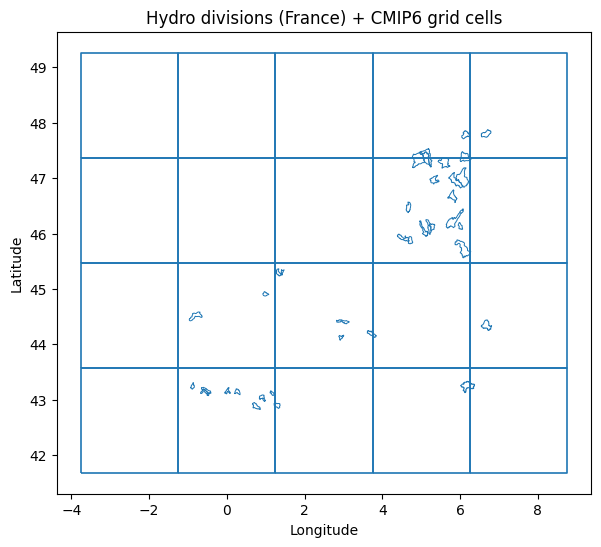

In [22]:
ax = gdf_hydro_div["france"].boundary.plot(figsize=(7, 6), linewidth=0.7)
grid_fr.boundary.plot(ax=ax, linewidth=1.2)
ax.set_title("Hydro divisions (France) + CMIP6 grid cells")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

Brazil grid rows: 4 | expected: 4


Text(29.722222222222214, 0.5, 'Latitude')

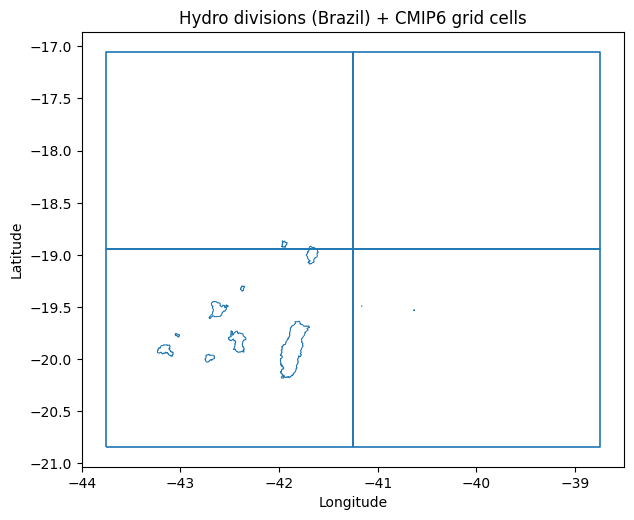

In [23]:
ds_br = subset_to_bbox(ds, BBOX["brazil"])
grid_br = build_grid_cells_gdf_bounds(ds_br)

print("Brazil grid rows:", len(grid_br), "| expected:", ds_br.sizes["lat"] * ds_br.sizes["lon"])

ax = gdf_hydro_div["brazil"].boundary.plot(figsize=(7, 6), linewidth=0.7)
grid_br.boundary.plot(ax=ax, linewidth=1.2)
ax.set_title("Hydro divisions (Brazil) + CMIP6 grid cells")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")


Build subsets + grid cells (France + Brazil)

In [24]:
def sanitize(s: str) -> str:
    s = s.strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return s.strip("_")

def is_bounds_var(v: str) -> bool:
    v = v.lower()
    return v.endswith("_bnds") or v in ("time_bnds", "lat_bnds", "lon_bnds")

def weekly_agg_for_var(var_name: str) -> str:
    """
    Heuristic:
      - precipitation-like => sum
      - everything else => mean
    Extend as you add more variables.
    """
    v = var_name.lower()
    if v in ("pr", "tp") or "precip" in v or "rain" in v:
        return "sum"
    return "mean"

#### 2. weighted averages using CIMP6 Data

In [25]:
def build_intersection_weights_from_grid(
    grid_cells: gpd.GeoDataFrame,
    hydro_gdf: gpd.GeoDataFrame,
    hydro_id_col: str = "hydro_id",
    equal_area_crs: str = "EPSG:6933",
) -> pd.DataFrame:
    """
    Compute polygon-grid intersection weights.

    Returns columns:
      hydro_id, ilat, ilon, weight

    weight = Area(hydro intersec cell) / sum_j Area(hydro intersec cell_j)
    """
    hydro = hydro_gdf[[hydro_id_col, "geometry"]].copy()
    grid  = grid_cells[["ilat", "ilon", "geometry"]].copy()

    if hydro.crs is None:
        hydro = hydro.set_crs("EPSG:4326")
    if grid.crs is None:
        grid = grid.set_crs("EPSG:4326")

    hydro_ea = hydro.to_crs(equal_area_crs)
    grid_ea  = grid.to_crs(equal_area_crs)

    cand = gpd.sjoin(grid_ea, hydro_ea, predicate="intersects", how="inner")

    left = cand.geometry
    right = hydro_ea.geometry.loc[cand["index_right"]]
    right.index = cand.index

    inter = left.intersection(right, align=False)
    cand["inter_area"] = inter.area
    cand = cand[cand["inter_area"] > 0].copy()

    denom = cand.groupby(hydro_id_col)["inter_area"].transform("sum")
    cand["weight"] = cand["inter_area"] / denom

    return cand[[hydro_id_col, "ilat", "ilon", "weight"]].rename(columns={hydro_id_col: "hydro_id"})

def apply_weights_timeseries(
    ds: xr.Dataset,
    var_name: str,
    weights_df: pd.DataFrame,
    lat_name: str = "lat",
    lon_name: str = "lon",
    time_name: str = "time",
) -> pd.DataFrame:
    """
    Apply intersection weights to ds[var_name] to get hydro-weighted time series.

    Input:
      ds[var_name] dims: (time, lat, lon)
      weights_df columns: hydro_id, ilat, ilon, weight

    Output:
      DataFrame columns: hydro_id, time, value
    """
    da = ds[var_name]

    if time_name in da.dims and lat_name in da.dims and lon_name in da.dims:
        da = da.transpose(time_name, lat_name, lon_name)

    ilats = np.sort(weights_df["ilat"].unique())
    ilons = np.sort(weights_df["ilon"].unique())

    da_sub = da.isel({lat_name: ilats, lon_name: ilons})  # time x lat x lon

    lat_map = {ilat: i for i, ilat in enumerate(ilats)}
    lon_map = {ilon: j for j, ilon in enumerate(ilons)}

    w = weights_df.copy()
    w["ilat_local"] = w["ilat"].map(lat_map)
    w["ilon_local"] = w["ilon"].map(lon_map)

    da_cells = da_sub.stack(cell=(lat_name, lon_name))  # time x cell

    #  cell = ilat_local * nlon + ilon_local
    nlon = len(ilons)
    w["cell"] = w["ilat_local"] * nlon + w["ilon_local"]

    # build weights matrix
    out_rows = []
    times = da_cells[time_name].values

    values = da_cells.values

    for hydro_id, g in w.groupby("hydro_id"):
        cell_idx = g["cell"].to_numpy(dtype=int)
        wts = g["weight"].to_numpy(dtype=float)

        # weighted mean per time (time,)
        hydro_vals = (values[:, cell_idx] * wts[None, :]).sum(axis=1)
        out_rows.append(
            pd.DataFrame({"hydro_id": hydro_id, "time": times, "value": hydro_vals})
        )

    return pd.concat(out_rows, ignore_index=True)

def weekly_resample_hydro(df: pd.DataFrame, agg: str) -> pd.DataFrame:
    """
    Input columns: hydro_id, time, value
    Output columns: hydro_id, ObsDate, value
    """
    xr_da = df.set_index(["hydro_id", "time"])["value"].to_xarray()

    if agg == "sum":
        xr_week = xr_da.resample(time="7D").sum()
    else:
        xr_week = xr_da.resample(time="7D").mean()

    out = xr_week.to_dataframe(name="value").reset_index()

    try:
        out["time"] = pd.to_datetime(out["time"])
    except TypeError:
        t = xr.CFTimeIndex(out["time"].values)
        out["time"] = t.to_datetimeindex()

    out["ObsDate"] = out["time"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
    out = out.drop(columns=["time"])
    return out

#### 3. Loop over CIMP6 Data

In [26]:
weights_cache = {}   # (ds_key, area) -> weights_df
feature_tables = []  # one table per (ds_key,var)

for ds_key, ds in cmip6_dsets.items():
    print(f"\n=== Dataset: {ds_key} ===")
    ds = normalize_lon_180(ds)

    real_vars = [v for v in ds.data_vars if not is_bounds_var(v)]
    if not real_vars:
        print("  -> no real variables found, skipping")
        continue

    for var_name in real_vars:
        agg = weekly_agg_for_var(var_name)
        feat_col = f"cmip6_{sanitize(ds_key)}_{sanitize(var_name)}_{HYDRO_LEVEL}"
        per_area_week = []

        for area in AREAS:
            ds_area = subset_to_bbox(ds, BBOX[area])

            if ds_area.sizes.get("lat", 0) == 0 or ds_area.sizes.get("lon", 0) == 0:
                print(f"  [{area}] empty after bbox -> skip")
                continue

            cache_key = (ds_key, area)
            if cache_key not in weights_cache:
                grid = build_grid_cells_gdf_bounds(ds_area)
                wdf = build_intersection_weights_from_grid(
                    grid_cells=grid,
                    hydro_gdf=gdf_hydro_div[area],
                    hydro_id_col="hydro_id",
                    equal_area_crs=EQUAL_AREA,
                )
                weights_cache[cache_key] = wdf
                print(f"  [{area}] weights built: rows={len(wdf)} | hydros={wdf['hydro_id'].nunique()}")
            else:
                wdf = weights_cache[cache_key]

            print(f"    [{area}] var={var_name} weekly_agg={agg}")

            df_daily = apply_weights_timeseries(ds_area, var_name, wdf)
            df_week  = weekly_resample_hydro(df_daily, agg=agg)
            df_week  = df_week.rename(columns={"value": feat_col})

            per_area_week.append(df_week[["hydro_id", "ObsDate", feat_col]])

        if per_area_week:
            df_feat = pd.concat(per_area_week, ignore_index=True)
            feature_tables.append(df_feat)

# merge feature tables
if not feature_tables:
    raise RuntimeError("No CMIP6 features generated.")

weekly_cmip6 = feature_tables[0]
for df in feature_tables[1:]:
    weekly_cmip6 = weekly_cmip6.merge(df, on=["hydro_id", "ObsDate"], how="outer")
weekly_cmip6 = weekly_cmip6.copy()

print("\n weekly_cmip6 shape:", weekly_cmip6.shape)
print("Columns (sample):", list(weekly_cmip6.columns)[:10])
weekly_cmip6.head()


=== Dataset: sfcWind__day__CESM2-FV2__historical__r1i1p1f1__gn ===
  [brazil] weights built: rows=13 | hydros=12
    [brazil] var=sfcWind weekly_agg=mean


C:\Users\nazim\AppData\Local\Temp\ipykernel_13824\1351904975.py:118: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  out["time"] = t.to_datetimeindex()
C:\Users\nazim\AppData\Local\Temp\ipykernel_13824\1351904975.py:118: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  out["time"] = t.to_datetimeindex()


  [france] weights built: rows=49 | hydros=38
    [france] var=sfcWind weekly_agg=mean


C:\Users\nazim\AppData\Local\Temp\ipykernel_13824\1351904975.py:118: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  out["time"] = t.to_datetimeindex()
C:\Users\nazim\AppData\Local\Temp\ipykernel_13824\1351904975.py:118: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  out["time"] = t.to_datetimeindex()



 weekly_cmip6 shape: (52150, 3)
Columns (sample): ['hydro_id', 'ObsDate', 'cmip6_sfcwind_day_cesm2_fv2_historical_r1i1p1f1_gn_sfcwind_zone']


,hydro_id,ObsDate,cmip6_sfcwind_day_cesm2_fv2_historical_r1i1p1f1_gn_sfcwind_zone
0,BRAZIL_1345571,1990-01-07,5.789862
1,BRAZIL_1345571,1990-01-14,5.050700
2,BRAZIL_1345571,1990-01-21,5.552589
3,BRAZIL_1345571,1990-01-28,4.318530
4,BRAZIL_1345571,1990-02-04,4.418843


#### 4. Merge CMIP6 Data to Baseline Data

In [27]:
station_to_hydro = station_to_hydro_map[HYDRO_LEVEL].copy()
station_to_hydro["station_code"] = station_to_hydro["station_code"].astype(str)
station_to_hydro["hydro_id"] = station_to_hydro["hydro_id"].astype(str)

# hydro_id -> station_code
hydro_to_station = station_to_hydro[["hydro_id", "station_code"]].copy()

print("Rows hydro_to_station:", len(hydro_to_station))
print("Unique hydros:", hydro_to_station["hydro_id"].nunique())
print("Unique stations:", hydro_to_station["station_code"].nunique())
hydro_to_station.head()

Rows hydro_to_station: 52
Unique hydros: 50
Unique stations: 52


,hydro_id,station_code
0,BRAZIL_1345662,56960005
1,BRAZIL_1345859,56850000
2,BRAZIL_1345614,56990000
3,BRAZIL_1346125,56610000
4,BRAZIL_1346195,56425000


In [28]:
weekly_cmip6_station = (
    weekly_cmip6.copy()
    .assign(hydro_id=lambda d: d["hydro_id"].astype(str))
    .merge(hydro_to_station, on="hydro_id", how="inner") 
)

weekly_cmip6_station = weekly_cmip6_station.drop(columns=["hydro_id"])

weekly_cmip6_station["station_code"] = weekly_cmip6_station["station_code"].astype(str)
weekly_cmip6_station["ObsDate"] = pd.to_datetime(weekly_cmip6_station["ObsDate"], errors="raise").dt.normalize()

weekly_cmip6_station = weekly_cmip6_station.drop_duplicates(subset=["station_code", "ObsDate"])
weekly_cmip6_station.head()

,ObsDate,cmip6_sfcwind_day_cesm2_fv2_historical_r1i1p1f1_gn_sfcwind_zone,station_code
0,1990-01-07,5.789862,56994500
1,1990-01-14,5.050700,56994500
2,1990-01-21,5.552589,56994500
3,1990-01-28,4.318530,56994500
4,1990-02-04,4.418843,56994500


In [29]:
cmip6_cols = [c for c in weekly_cmip6_station.columns if c.startswith("cmip6_")]

dataset_train_aug = (
    dataset_train.reset_index()
    .assign(station_code=lambda d: d["station_code"].astype(str))
    .merge(
        weekly_cmip6_station[["station_code", "ObsDate"] + cmip6_cols],
        on=["station_code", "ObsDate"],
        how="left"
    )
    .set_index("ObsDate")
    .sort_index()
)

dataset_eval_aug = (
    dataset_eval.reset_index()
    .assign(station_code=lambda d: d["station_code"].astype(str))
    .merge(
        weekly_cmip6_station[["station_code", "ObsDate"] + cmip6_cols],
        on=["station_code", "ObsDate"],
        how="left"
    )
    .set_index("ObsDate")
    .sort_index()
)

print("Train:", dataset_train.shape, "→", dataset_train_aug.shape)
print("Eval :", dataset_eval.shape,  "→", dataset_eval_aug.shape)

print("Train CMIP6 missing avg:", float(dataset_train_aug[cmip6_cols].isna().mean().mean()))
print("Eval  CMIP6 missing avg:", float(dataset_eval_aug[cmip6_cols].isna().mean().mean()))


Train: (28509, 157) → (28509, 158)
Eval : (1352, 153) → (1352, 154)
Train CMIP6 missing avg: 0.0
Eval  CMIP6 missing avg: 0.0


C:\Users\nazim\AppData\Local\Temp\ipykernel_13824\1510362947.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset_train.reset_index()
C:\Users\nazim\AppData\Local\Temp\ipykernel_13824\1510362947.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset_eval.reset_index()


In [30]:
def rename_cmip6_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    cmip6_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("cmip6_")]

    counts = defaultdict(int)
    rename_map = {}

    for c in cmip6_cols:
        base = c.split("_")[1]
        counts[base] += 1
        new_name = base if counts[base] == 1 else f"{base}_{counts[base]}"
        rename_map[c] = new_name

    return df.rename(columns=rename_map)

dataset_train_aug = rename_cmip6_cols(dataset_train_aug)
dataset_eval_aug  = rename_cmip6_cols(dataset_eval_aug)

In [31]:
train_fp = INPUT_DIR / "dataset_train_aug_cmip6.csv"
eval_fp  = EVAL_DIR / "dataset_eval_aug_cmip6.csv"

dataset_train_aug.to_csv(train_fp, index=True)
dataset_eval_aug.to_csv(eval_fp, index=True)